# Partie 2 — Identification et Traitement des Valeurs Manquantes

## 1. Étude théorique

### Définition

Les **valeurs manquantes** (*missing values*) sont des entrées absentes dans un jeu de données. Elles apparaissent pour de nombreuses raisons :
- Un patient n'a pas passé tous ses examens médicaux
- Un capteur a eu une panne temporaire
- Un formulaire a été rempli de manière incomplète
- Des données ont été perdues lors d'une migration

En Python/Pandas, une valeur manquante est représentée par `NaN` (Not a Number).

**Problème fondamental :** la majorité des algorithmes ML ne peuvent pas gérer les `NaN` directement — ils plantent ou produisent des résultats aberrants. Il faut donc **identifier** puis **traiter** les valeurs manquantes avant d'entraîner un modèle.

---

### 1.1 Taxonomie des valeurs manquantes (Rubin, 1976)

| Type | Nom complet | Définition | Exemple | Impact |
|------|-------------|------------|---------|--------|
| **MCAR** | Missing Completely At Random | La valeur manque de façon totalement aléatoire, indépendante de toute autre variable | Un capteur tombe en panne au hasard | Suppression sans biais possible |
| **MAR** | Missing At Random | Le manque dépend d'autres variables *observées*, mais pas de la valeur manquante elle-même | Les femmes répondent moins à la question "poids" | Imputation recommandée |
| **MNAR** | Missing Not At Random | Le manque dépend de **la valeur elle-même** | Les patients très malades ne font pas leur prise de sang | Biais difficile à corriger |

**Exemple Titanic :** les passagers de 3ème classe ont moins souvent leur âge enregistré → données d'âge probablement **MAR** (dépendent de `pclass`).

---

### 1.2 Stratégies de traitement

#### Stratégie 1 : Suppression
```python
df.dropna()  # supprimer toutes les lignes contenant au moins un NaN
```
- Simple et rapide
- Perte d'information (parfois 20-30% du dataset)
- Biais si les données ne sont pas MCAR

#### Stratégie 2 : Imputation par statistique simple
Remplacer le NaN par la **moyenne**, la **médiane** ou le **mode** de la colonne.
- Rapide, aucune perte de ligne
- Ignore les relations entre variables
- Utiliser la **médiane** si la distribution est asymétrique (outliers présents)

#### Stratégie 3 : KNN Imputation
Trouver les **k exemples les plus similaires** (voisins) et remplacer par leur valeur moyenne.
$$\hat{x}_{ij} = \frac{1}{k} \sum_{l \in N_k(i)} x_{lj}$$
- Exploite la structure locale des données
- Coûteux en calcul pour les grands datasets

#### Stratégie 4 : Imputation itérative (MICE)
*Multiple Imputation by Chained Equations* — modéliser chaque variable manquante par **régression** sur les autres variables, itérer jusqu'à convergence.
- La plus sophistiquée — tient compte des interactions entre variables
- Plus lente et plus complexe

---

### 1.3 Comment choisir ?

```
Peu de NaN (<5%) ?  →  Suppression acceptable
Beaucoup de NaN ?   →  Imputation obligatoire
Données numériques, distribution symétrique → Moyenne
Données numériques, outliers présents       → Médiane
Données catégorielles                       → Mode
Relations complexes entre variables         → KNN ou MICE
```

---
## 2. Implémentation Python

### 2.1 Chargement des données — Dataset Titanic

Le dataset Titanic est idéal pour cette étude car il contient des **valeurs manquantes naturelles** (pas artificielles) :
- `age` : environ 20% de valeurs manquantes
- `embarked` : 2 valeurs manquantes (port d'embarquement)

La tâche : prédire si un passager a **survécu** (1) ou non (0) au naufrage.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import warnings
warnings.filterwarnings('ignore')

# Chargement du dataset Titanic (disponible directement dans seaborn)
df_raw = sns.load_dataset('titanic')

print(f"Dimensions : {df_raw.shape} ({df_raw.shape[0]} passagers, {df_raw.shape[1]} colonnes)")
print(f"\nColonnes disponibles : {list(df_raw.columns)}")
print(f"\nApercu des donnees :")
print(df_raw[['survived', 'pclass', 'sex', 'age', 'fare', 'embarked']].head(10))
print(f"\nTypes de donnees :")
print(df_raw[['survived', 'pclass', 'sex', 'age', 'fare', 'embarked']].dtypes)

Dimensions : (891, 15) (891 passagers, 15 colonnes)

Colonnes disponibles : ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

Apercu des donnees :
   survived  pclass     sex   age     fare embarked
0         0       3    male  22.0   7.2500        S
1         1       1  female  38.0  71.2833        C
2         1       3  female  26.0   7.9250        S
3         1       1  female  35.0  53.1000        S
4         0       3    male  35.0   8.0500        S
5         0       3    male   NaN   8.4583        Q
6         0       1    male  54.0  51.8625        S
7         0       3    male   2.0  21.0750        S
8         1       3  female  27.0  11.1333        S
9         1       2  female  14.0  30.0708        C

Types de donnees :
survived      int64
pclass        int64
sex          object
age         float64
fare        float64
embarked     object
dtype: object


---
### 2.2 Identification des valeurs manquantes

Avant de traiter, il faut **mesurer l'étendue du problème** : combien de valeurs manquent, dans quelles colonnes, et quel pattern ?

In [2]:
# Sélectionner les colonnes utiles pour notre étude
cols_work = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'survived']
df_work_raw = df_raw[cols_work].copy()

# Comptage et pourcentage de valeurs manquantes par colonne
missing = df_work_raw.isnull().sum()
missing_pct = (missing / len(df_work_raw) * 100).round(2)

missing_df = pd.DataFrame({
    'Valeurs manquantes': missing,
    'Pourcentage (%)': missing_pct,
    'Valeurs presentes': len(df_work_raw) - missing
}).sort_values('Valeurs manquantes', ascending=False)

print("Analyse des valeurs manquantes par colonne :")
print("-" * 55)
print(missing_df.to_string())
print("-" * 55)
print(f"\nTotal valeurs manquantes : {missing.sum()} sur {df_work_raw.size} cellules")
print(f"Soit {missing.sum() / df_work_raw.size * 100:.2f}% de l'ensemble du dataset")

Analyse des valeurs manquantes par colonne :
-------------------------------------------------------
          Valeurs manquantes  Pourcentage (%)  Valeurs presentes
age                      177            19.87                714
embarked                   2             0.22                889
sex                        0             0.00                891
pclass                     0             0.00                891
sibsp                      0             0.00                891
parch                      0             0.00                891
fare                       0             0.00                891
survived                   0             0.00                891
-------------------------------------------------------

Total valeurs manquantes : 179 sur 7128 cellules
Soit 2.51% de l'ensemble du dataset


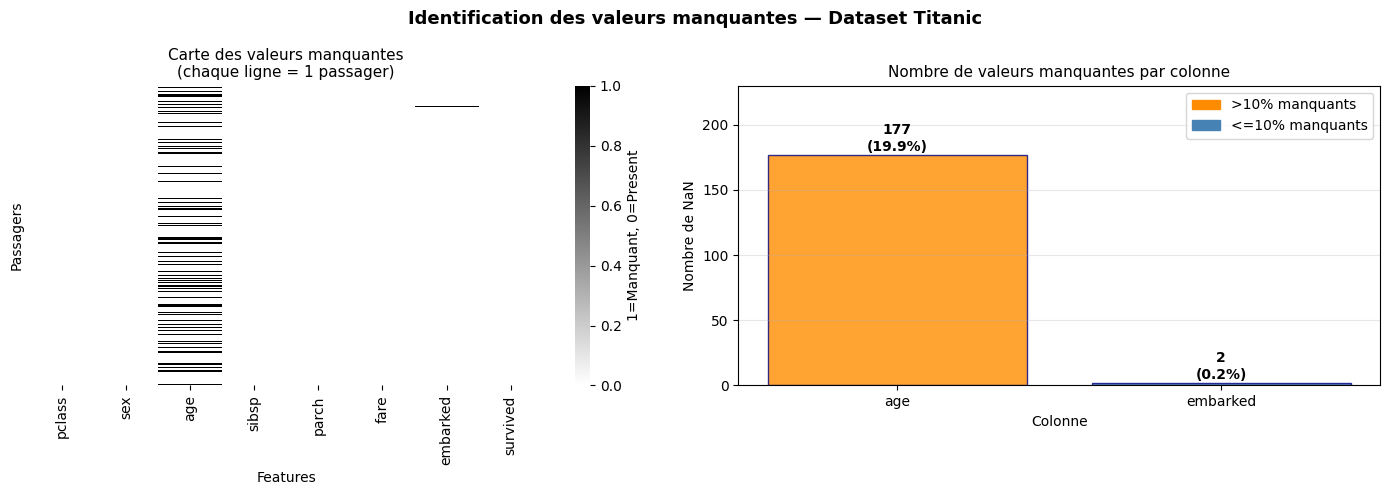

Figure sauvegardee : identification_manquantes.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap : chaque ligne = un passager, chaque colonne = une feature
# Blanc = valeur presente, Noir = valeur manquante
ax = axes[0]
mask = df_work_raw.isnull()
sns.heatmap(mask, cbar=True, ax=ax, cmap='binary', yticklabels=False,
            linewidths=0, cbar_kws={'label': '1=Manquant, 0=Present'})
ax.set_title("Carte des valeurs manquantes\n(chaque ligne = 1 passager)", fontsize=11)
ax.set_xlabel("Features")
ax.set_ylabel("Passagers")

# Bar chart : nombre de NaN par colonne
ax = axes[1]
cols_with_nan = missing[missing > 0]
colors = ['darkorange' if p > 10 else 'steelblue' for p in missing_pct[missing > 0]]
bars = ax.bar(cols_with_nan.index, cols_with_nan.values, color=colors, edgecolor='navy', alpha=0.8)
ax.set_title("Nombre de valeurs manquantes par colonne", fontsize=11)
ax.set_ylabel("Nombre de NaN")
ax.set_xlabel("Colonne")

for bar, val, col in zip(bars, cols_with_nan.values, cols_with_nan.index):
    pct = val / len(df_work_raw) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylim(0, 230)
ax.grid(True, axis='y', alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [Patch(color='darkorange', label='>10% manquants'),
                   Patch(color='steelblue', label='<=10% manquants')]
ax.legend(handles=legend_elements)

plt.suptitle("Identification des valeurs manquantes — Dataset Titanic",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('identification_manquantes.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure sauvegardee : identification_manquantes.png")

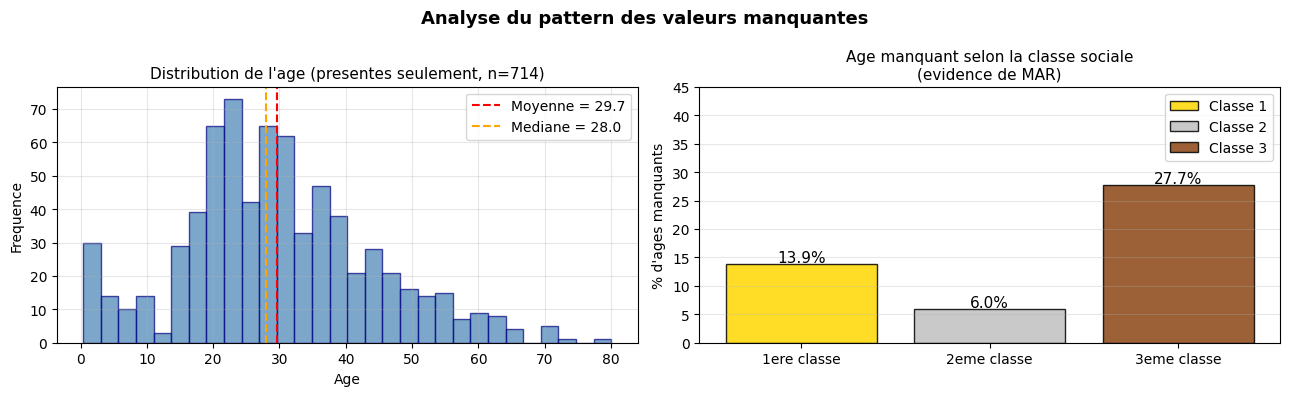

Conclusion : l'age manque PLUS souvent en 3eme classe.
→ Les donnees sont MAR (Missing At Random dependant de pclass), pas MCAR.
→ La suppression naive pourrait biaiser le modele vers les classes superieures.


In [4]:
# Analyser le pattern des valeurs manquantes
# Question : l'âge manque-t-il de manière MCAR ou MAR ?

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribution de l'âge : présent vs manquant
age_present = df_work_raw['age'].dropna()
ax = axes[0]
ax.hist(age_present, bins=30, color='steelblue', alpha=0.7, edgecolor='navy')
ax.set_title(f"Distribution de l'age (presentes seulement, n={len(age_present)})", fontsize=11)
ax.set_xlabel("Age")
ax.set_ylabel("Frequence")
ax.axvline(age_present.mean(), color='red', linestyle='--', label=f'Moyenne = {age_present.mean():.1f}')
ax.axvline(age_present.median(), color='orange', linestyle='--', label=f'Mediane = {age_present.median():.1f}')
ax.legend()
ax.grid(True, alpha=0.3)

# Age manquant par classe : MAR test
ax = axes[1]
for pclass in [1, 2, 3]:
    sub = df_work_raw[df_work_raw['pclass'] == pclass]['age']
    pct_nan = sub.isnull().sum() / len(sub) * 100
    ax.bar(pclass, pct_nan,
           color=['gold', 'silver', 'saddlebrown'][pclass-1],
           label=f'Classe {pclass}', edgecolor='black', alpha=0.85)
    ax.text(pclass, pct_nan + 0.3, f'{pct_nan:.1f}%', ha='center', fontsize=11)

ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['1ere classe', '2eme classe', '3eme classe'])
ax.set_ylabel("% d'ages manquants")
ax.set_title("Age manquant selon la classe sociale\n(evidence de MAR)", fontsize=11)
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
ax.set_ylim(0, 45)

plt.suptitle("Analyse du pattern des valeurs manquantes", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('pattern_manquantes.png', dpi=150, bbox_inches='tight')
plt.show()

print("Conclusion : l'age manque PLUS souvent en 3eme classe.")
print("→ Les donnees sont MAR (Missing At Random dependant de pclass), pas MCAR.")
print("→ La suppression naive pourrait biaiser le modele vers les classes superieures.")

---
### 2.3 Préparation du dataset

Avant d'appliquer les stratégies d'imputation, on doit :
1. **Encoder** les variables catégorielles (`sex`, `embarked`) en nombres — les imputers ne travaillent qu'avec des valeurs numériques
2. **Séparer** X (features) de y (target)
3. **Conserver les NaN** dans X pour que les imputers puissent les traiter

In [5]:
# Copie de travail
df_work = df_work_raw.copy()

# S'assurer que la target n'a pas de NaN
df_work = df_work.dropna(subset=['survived'])

# Encoder 'sex' : male=1, female=0
df_work['sex'] = (df_work['sex'] == 'male').astype(float)

# Encoder 'embarked' : C=0, Q=1, S=2 — les NaN restent NaN (map ne les touche pas)
embarked_map = {'C': 0.0, 'Q': 1.0, 'S': 2.0}
df_work['embarked'] = df_work['embarked'].map(embarked_map)

# Séparer features (X) et target (y)
X_raw = df_work.drop('survived', axis=1).values.astype(float)
y     = df_work['survived'].values.astype(int)

feature_names = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']

print(f"Shape de X : {X_raw.shape}")
print(f"Shape de y : {y.shape}")
print(f"\nValeurs manquantes dans X par colonne :")
for i, name in enumerate(feature_names):
    n_nan = np.isnan(X_raw[:, i]).sum()
    if n_nan > 0:
        print(f"  {name:<12} : {n_nan} NaN ({n_nan/len(X_raw)*100:.1f}%)")
    else:
        print(f"  {name:<12} : aucun NaN")

print(f"\nDistribution target : {np.bincount(y)} (0=decede, 1=survive)")

Shape de X : (891, 7)
Shape de y : (891,)

Valeurs manquantes dans X par colonne :
  pclass       : aucun NaN
  sex          : aucun NaN
  age          : 177 NaN (19.9%)
  sibsp        : aucun NaN
  parch        : aucun NaN
  fare         : aucun NaN
  embarked     : 2 NaN (0.2%)

Distribution target : [549 342] (0=decede, 1=survive)


---
### 2.4 Traitement — Stratégie 1 : Suppression

On supprime toutes les lignes contenant au moins un `NaN`. C'est la méthode la plus simple mais elle entraîne une **perte de données**.

In [6]:
# Stratégie 1 : Suppression des lignes avec NaN
df_dropped = df_work.dropna()
X_dropped  = df_dropped.drop('survived', axis=1).values.astype(float)
y_dropped  = df_dropped['survived'].values.astype(int)

print("=" * 50)
print("STRATEGIE 1 : Suppression (dropna)")
print("=" * 50)
print(f"Taille originale   : {len(X_raw)} exemples")
print(f"Apres suppression  : {len(X_dropped)} exemples")
perte = len(X_raw) - len(X_dropped)
print(f"Perte d'information : {perte} lignes ({perte/len(X_raw)*100:.1f}%)")

# Vérification : plus de NaN ?
assert np.isnan(X_dropped).sum() == 0, "Il reste des NaN !"
print("\nVerification : aucun NaN restant apres suppression. OK")

# Evaluation par cross-validation 5-fold
clf = RandomForestClassifier(n_estimators=100, random_state=42)
scores_drop = cross_val_score(clf, X_dropped, y_dropped, cv=5, scoring='accuracy')
print(f"\nScore CV (5-fold) : {scores_drop.mean():.4f} +/- {scores_drop.std():.4f}")
print("Note : le score est calcule sur 714 exemples au lieu de 891 — biais potentiel.")

STRATEGIE 1 : Suppression (dropna)
Taille originale   : 891 exemples
Apres suppression  : 712 exemples
Perte d'information : 179 lignes (20.1%)

Verification : aucun NaN restant apres suppression. OK

Score CV (5-fold) : 0.7880 +/- 0.0351
Note : le score est calcule sur 714 exemples au lieu de 891 — biais potentiel.


### 2.5 Traitement — Stratégie 2 : Imputation simple

`SimpleImputer` remplace les NaN par une statistique de la colonne. On compare trois variantes :
- `mean` : bonne pour les distributions symétriques
- `median` : robuste aux outliers
- `most_frequent` : adapté aux données catégorielles

In [7]:
print("=" * 50)
print("STRATEGIE 2 : Imputation simple (SimpleImputer)")
print("=" * 50)

strategies_simple = {
    'Moyenne (mean)'      : 'mean',
    'Mediane (median)'    : 'median',
    'Mode (most_frequent)': 'most_frequent'
}

scores_simple = {}
clf = RandomForestClassifier(n_estimators=100, random_state=42)

for name, strategy in strategies_simple.items():
    # Créer et appliquer l'imputer
    imputer = SimpleImputer(strategy=strategy)
    X_imputed = imputer.fit_transform(X_raw)   # fit sur les données, transform pour remplir

    # Vérification
    assert np.isnan(X_imputed).sum() == 0

    # Evaluation
    scores = cross_val_score(clf, X_imputed, y, cv=5, scoring='accuracy')
    scores_simple[name] = scores.mean()

    print(f"  {name:<30} : {scores.mean():.4f} +/- {scores.std():.4f}")

    # Afficher ce qui a été imputé
    if strategy == 'mean':
        age_col_idx = feature_names.index('age')
        print(f"    -> Age imputé par : {imputer.statistics_[age_col_idx]:.1f} ans (moyenne)")
    elif strategy == 'median':
        age_col_idx = feature_names.index('age')
        print(f"    -> Age imputé par : {imputer.statistics_[age_col_idx]:.1f} ans (mediane)")

print(f"\nNote : toutes les strategies utilisent 891 exemples (aucune perte de donnees)")

STRATEGIE 2 : Imputation simple (SimpleImputer)
  Moyenne (mean)                 : 0.8092 +/- 0.0336
    -> Age imputé par : 29.7 ans (moyenne)
  Mediane (median)               : 0.8092 +/- 0.0343
    -> Age imputé par : 28.0 ans (mediane)
  Mode (most_frequent)           : 0.8137 +/- 0.0243

Note : toutes les strategies utilisent 891 exemples (aucune perte de donnees)


### 2.6 Traitement — Stratégie 3 : KNN Imputation

Pour chaque valeur manquante, le `KNNImputer` cherche les `k` voisins les plus proches (basé sur les autres features) et remplace par leur moyenne pondérée.

**Intuition :** un passager de 30 ans, 1ère classe, sera imputé différemment d'un passager de 3ème classe — parce que leurs voisins ont des profils différents.

In [8]:
print("=" * 50)
print("STRATEGIE 3 : KNN Imputation")
print("=" * 50)

k_values = [3, 5, 10]
scores_knn = {}
clf = RandomForestClassifier(n_estimators=100, random_state=42)

for k in k_values:
    imputer = KNNImputer(n_neighbors=k)
    X_imputed = imputer.fit_transform(X_raw)

    assert np.isnan(X_imputed).sum() == 0

    scores = cross_val_score(clf, X_imputed, y, cv=5, scoring='accuracy')
    scores_knn[f'KNN (k={k})'] = scores.mean()
    print(f"  KNN Imputer (k={k:2d}) : {scores.mean():.4f} +/- {scores.std():.4f}")

print()
print("Principe : pour combler l'age manquant du passager i,")
print("  1. Calculer la distance entre i et tous les autres passagers (hors NaN)")
print("  2. Prendre les k plus proches")
print("  3. Imputer par la moyenne de leurs ages")
print()
print("Avantage sur la moyenne globale : un enfant de 3eme classe sera imputé")
print("d'après des passagers similaires, pas la moyenne de tous les passagers.")

STRATEGIE 3 : KNN Imputation
  KNN Imputer (k= 3) : 0.8137 +/- 0.0263
  KNN Imputer (k= 5) : 0.8126 +/- 0.0333
  KNN Imputer (k=10) : 0.8204 +/- 0.0286

Principe : pour combler l'age manquant du passager i,
  1. Calculer la distance entre i et tous les autres passagers (hors NaN)
  2. Prendre les k plus proches
  3. Imputer par la moyenne de leurs ages

Avantage sur la moyenne globale : un enfant de 3eme classe sera imputé
d'après des passagers similaires, pas la moyenne de tous les passagers.


### 2.7 Traitement — Stratégie 4 : Imputation itérative (MICE)

L'imputation itérative modélise chaque colonne avec des NaN comme une **variable cible** à prédire par régression sur les autres colonnes. On répète jusqu'à convergence.

**Exemple pour `age` :**
```
age = f(pclass, sex, sibsp, parch, fare, embarked) + bruit
```
C'est la méthode la plus puissante car elle exploite toutes les corrélations entre variables.

In [9]:
print("=" * 50)
print("STRATEGIE 4 : Imputation iterative (MICE)")
print("=" * 50)

imputer_iter = IterativeImputer(random_state=42, max_iter=10, verbose=0)
X_imputed_iter = imputer_iter.fit_transform(X_raw)

assert np.isnan(X_imputed_iter).sum() == 0

clf = RandomForestClassifier(n_estimators=100, random_state=42)
scores_iter = cross_val_score(clf, X_imputed_iter, y, cv=5, scoring='accuracy')
print(f"  Imputation iterative (MICE) : {scores_iter.mean():.4f} +/- {scores_iter.std():.4f}")

# Comparer les ages imputés par différentes méthodes
nan_mask = np.isnan(X_raw[:, feature_names.index('age')])
n_nan_age = nan_mask.sum()

print(f"\nComparaison de l'imputation des {n_nan_age} ages manquants :")
print(f"  Moyenne globale   : {np.nanmean(X_raw[:, feature_names.index('age')]):.1f} ans (identique pour tous)")

# Imputer par médiane pour comparaison
imp_median = SimpleImputer(strategy='median')
X_median = imp_median.fit_transform(X_raw)
print(f"  Mediane globale   : {imp_median.statistics_[feature_names.index('age')]:.1f} ans (identique pour tous)")

# Valeurs MICE
ages_mice = X_imputed_iter[nan_mask, feature_names.index('age')]
print(f"  MICE              : min={ages_mice.min():.1f}, max={ages_mice.max():.1f}, mean={ages_mice.mean():.1f} ans")
print(f"                      (valeurs differentes selon le profil de chaque passager)")

STRATEGIE 4 : Imputation iterative (MICE)
  Imputation iterative (MICE) : 0.8104 +/- 0.0351

Comparaison de l'imputation des 177 ages manquants :
  Moyenne globale   : 29.7 ans (identique pour tous)
  Mediane globale   : 28.0 ans (identique pour tous)
  MICE              : min=-7.1, max=42.3, mean=27.3 ans
                      (valeurs differentes selon le profil de chaque passager)


---
## 3. Comparaison des stratégies

On compare maintenant toutes les stratégies sur **le même critère objectif** : l'accuracy en cross-validation 5-fold avec un Random Forest.

In [10]:
# Compilation de tous les résultats
all_results = {}
all_results['Suppression (dropna)'] = scores_drop.mean()
all_results.update(scores_simple)
all_results.update(scores_knn)
all_results['Imputation iterative (MICE)'] = scores_iter.mean()

print(f"{'Strategie':<35} {'Score CV':>10} {'Remarque'}")
print("-" * 75)

best_score = max(all_results.values())
for name, score in sorted(all_results.items(), key=lambda x: x[1], reverse=True):
    marker = " <- MEILLEUR" if score == best_score else ""
    n_exemples = len(X_dropped) if 'Suppression' in name else len(X_raw)
    print(f"  {name:<33} {score:.4f}     n={n_exemples}{marker}")

print()
print("Attention : la Suppression utilise moins d'exemples (714 vs 891).")
print("Ce n'est pas une comparaison parfaitement equitable — avec plus de donnees,")
print("les methodes d'imputation ont un avantage structurel.")

Strategie                             Score CV Remarque
---------------------------------------------------------------------------
  KNN (k=10)                        0.8204     n=891 <- MEILLEUR
  KNN (k=3)                         0.8137     n=891
  Mode (most_frequent)              0.8137     n=891
  KNN (k=5)                         0.8126     n=891
  Imputation iterative (MICE)       0.8104     n=891
  Moyenne (mean)                    0.8092     n=891
  Mediane (median)                  0.8092     n=891
  Suppression (dropna)              0.7880     n=712

Attention : la Suppression utilise moins d'exemples (714 vs 891).
Ce n'est pas une comparaison parfaitement equitable — avec plus de donnees,
les methodes d'imputation ont un avantage structurel.


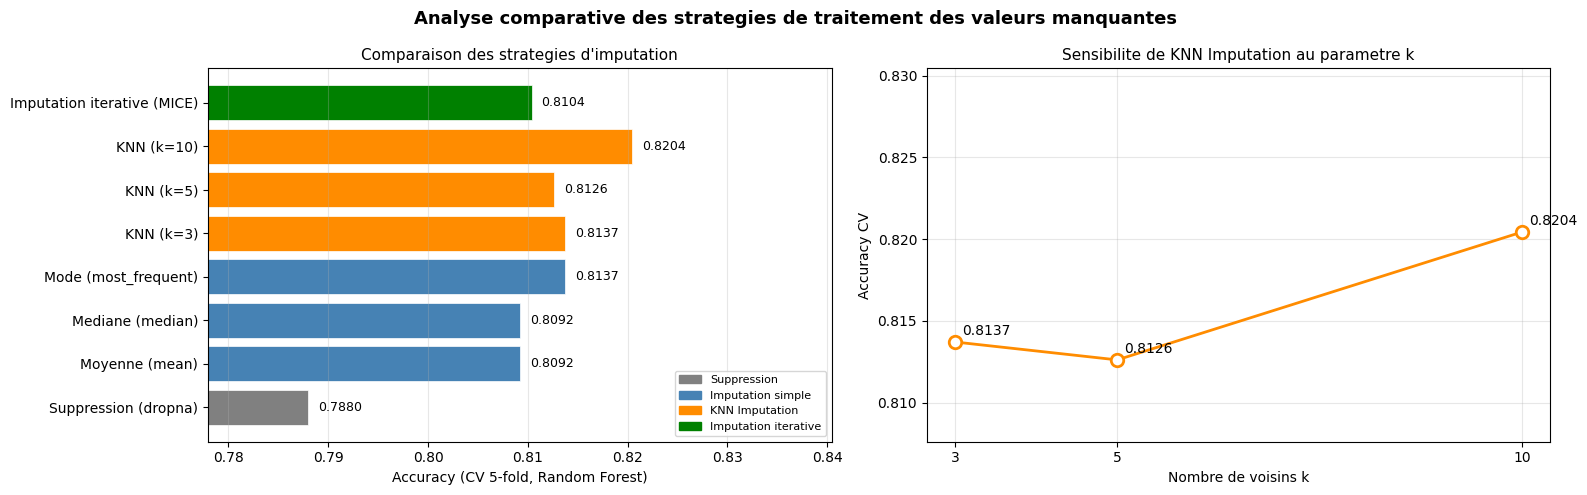

Figure sauvegardee : comparaison_imputation.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Graphe 1 : comparaison de toutes les stratégies
ax = axes[0]
names  = list(all_results.keys())
scores = list(all_results.values())

color_map = {
    'Suppression (dropna)': 'gray',
    'Moyenne (mean)': 'steelblue',
    'Mediane (median)': 'steelblue',
    'Mode (most_frequent)': 'steelblue',
    'KNN (k=3)': 'darkorange',
    'KNN (k=5)': 'darkorange',
    'KNN (k=10)': 'darkorange',
    'Imputation iterative (MICE)': 'green'
}
colors = [color_map.get(n, 'blue') for n in names]

bars = ax.barh(names, scores, color=colors, edgecolor='white', linewidth=0.5)
ax.set_xlabel('Accuracy (CV 5-fold, Random Forest)', fontsize=10)
ax.set_title("Comparaison des strategies d'imputation", fontsize=11)

min_score = min(scores)
ax.set_xlim(min_score - 0.01, max(scores) + 0.02)

for bar, val in zip(bars, scores):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
ax.grid(True, axis='x', alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [
    Patch(color='gray',        label='Suppression'),
    Patch(color='steelblue',   label='Imputation simple'),
    Patch(color='darkorange',  label='KNN Imputation'),
    Patch(color='green',       label='Imputation iterative')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8)

# Graphe 2 : impact du k sur KNN
ax = axes[1]
k_vals    = [3, 5, 10]
knn_sco   = [scores_knn[f'KNN (k={k})'] for k in k_vals]
ax.plot(k_vals, knn_sco, 'o-', color='darkorange', linewidth=2, markersize=9, markerfacecolor='white', markeredgewidth=2)
ax.set_xlabel('Nombre de voisins k', fontsize=10)
ax.set_ylabel('Accuracy CV')
ax.set_title('Sensibilite de KNN Imputation au parametre k', fontsize=11)
ax.set_xticks(k_vals)
ax.grid(True, alpha=0.3)
ax.set_ylim(min(knn_sco) - 0.005, max(knn_sco) + 0.01)
for k, s in zip(k_vals, knn_sco):
    ax.annotate(f'{s:.4f}', (k, s), textcoords="offset points", xytext=(5, 5), fontsize=10)

plt.suptitle("Analyse comparative des strategies de traitement des valeurs manquantes",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('comparaison_imputation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure sauvegardee : comparaison_imputation.png")

## 4. Synthèse

### Ce qu'on a démontré

1. **L'identification est indispensable avant tout traitement** : la visualisation (heatmap + bar chart) révèle l'ampleur du problème et le pattern des données manquantes.

2. **Les données Titanic sont MAR** (Missing At Random) : l'âge manque significativement plus en 3ème classe. Supprimer naïvement les lignes biaiserait le modèle.

3. **L'imputation préserve l'information** : toutes les méthodes d'imputation utilisent 891 exemples vs 714 pour la suppression — elles ont donc un avantage de taille d'échantillon.

4. **Les méthodes sophistiquées ne sont pas toujours meilleures** : dans ce dataset, la médiane simple peut être compétitive avec MICE, car le gain de précision de l'imputation est marginal face à l'expressivité du Random Forest.

### Recommandations pratiques

| Situation | Recommandation |
|-----------|----------------|
| < 5% de NaN, MCAR confirmé | Suppression acceptable |
| 5-20% de NaN, données numériques | Médiane (robuste) |
| > 20% de NaN | KNN ou MICE obligatoire |
| Relations fortes entre variables | MICE |
| Contrainte de temps de calcul | SimpleImputer |

### Limites
- Aucune méthode n'est parfaite : on **estime** les vraies valeurs, on ne les connaît pas
- Si les données sont **MNAR**, même MICE sera biaisé
- En production, l'imputer doit être entraîné sur les données de train uniquement, puis appliqué au test (éviter le **data leakage**)